#Credit Risk Assessment and Default Prediction using Machine Learning

## Objective

The objective of this project is to predict the probability of credit card default in the next month using customer demographics, repayment history, bill amount, payment amount, and credit utilization behavior.

The project focuses not only on model accuracy, but also on identifying high-risk customers early, which is important for credit risk monitoring and loss prevention.

## 1. Data Loading

The dataset is loaded into Python using Pandas for further analysis and modeling.

In [2]:
import pandas as pd

df  = pd.read_csv('UCI_Credit_Card.csv')

df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Dataset Overview

Understanding the dimensions, variables, and data types present in the dataset.

In [3]:
df.shape

(30000, 25)

Observation:
- The dataset contains 30,000 customer records.
- It consists of demographic, financial, repayment history, and default information.

## 3. Missing Value Analysis

Missing values can adversely affect model performance. Therefore, the dataset is examined for null values.

In [4]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


Observation:
- No missing values were found in the dataset.
- The dataset is complete and suitable for analysis.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 4. Duplicate Record Analysis

Duplicate records may bias the analysis and model results.

In [6]:
df.duplicated().sum()
df.nunique()

,0
ID,30000
LIMIT_BAL,81
SEX,2
EDUCATION,7
MARRIAGE,4
AGE,56
PAY_0,11
PAY_2,11
PAY_3,11
PAY_4,11



Observation:
- No duplicate observations were found in the dataset.

## 5. Column Renaming
Column names were renamed to make them more readable and easier to interpret during analysis.

In [7]:
#Rename Columns for Better Understanding

df = df.rename(columns={
    'LIMIT_BAL': 'Credit_Limit',
    'SEX': 'Gender',
    'EDUCATION': 'Education',
    'MARRIAGE': 'Marriage',
    'PAY_0': 'Repayment_Status_Sep',
    'PAY_2': 'Repayment_Status_Aug',
    'PAY_3': 'Repayment_Status_Jul',
    'PAY_4': 'Repayment_Status_Jun',
    'PAY_5': 'Repayment_Status_May',
    'PAY_6': 'Repayment_Status_Apr',
    'default.payment.next.month': 'Default'
})

## 6. Categorical Variable Validation
Categorical variables such as Gender, Education, and Marriage were checked for valid category values.



In [8]:
# Validate Categorical Variables

print("Gender values:")
display(df['Gender'].value_counts())

print("Education values:")
display(df['Education'].value_counts().sort_index())

print("Marriage values:")
display(df['Marriage'].value_counts().sort_index())

Gender values:


,count
Gender,
2,18112
1,11888


Education values:


,count
Education,
0,14
1,10585
2,14030
3,4917
4,123
5,280
6,51


Marriage values:


,count
Marriage,
0,54
1,13659
2,15964
3,323


Observation:
Some undefined categories were present in Education and Marriage.

## 7. Handling Undefined Categories
Undefined categories in Education and Marriage were grouped under the “Others” category.



In [9]:
# Handle Undefined Categories

# Education:
# 1 = Graduate School, 2 = University, 3 = High School, 4 = Others
# Values 0, 5, 6 are undefined, so merging them into 4 = Others

df['Education'] = df['Education'].replace([0, 5, 6], 4)

# Marriage:
# 1 = Married, 2 = Single, 3 = Others
# Value 0 is undefined, so merging into 3 = Others

df['Marriage'] = df['Marriage'].replace(0, 3)

In [10]:
# Map Categories for Readable EDA

df['Gender_Label'] = df['Gender'].map({
    1: 'Male',
    2: 'Female'
})

df['Education_Label'] = df['Education'].map({
    1: 'Graduate School',
    2: 'University',
    3: 'High School',
    4: 'Others'
})

df['Marriage_Label'] = df['Marriage'].map({
    1: 'Married',
    2: 'Single',
    3: 'Others'
})

**Observation:**  
This improves interpretability and avoids treating invalid codes as separate meaningful classes.

## 8. Target Variable Distribution
The target variable `Default` was analyzed to understand the proportion of defaulters and non-defaulters.



Default
0    23364
1     6636
Name: count, dtype: int64
Default
0    77.88
1    22.12
Name: proportion, dtype: float64


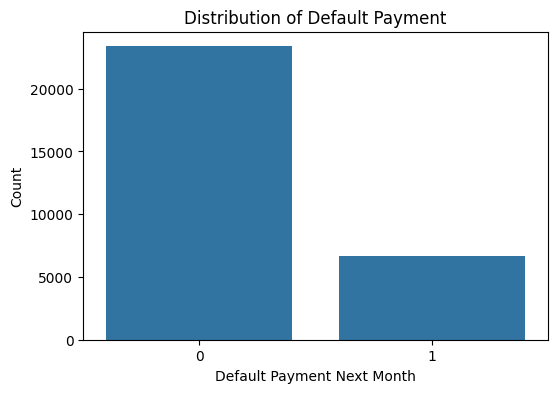

In [11]:
#Target Variable Distribution
import seaborn as sns
import matplotlib.pyplot as plt
print(df['Default'].value_counts())
print(df['Default'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(x='Default', data=df)
plt.title('Distribution of Default Payment')
plt.xlabel('Default Payment Next Month')
plt.ylabel('Count')
plt.show()

**Observation:**  
The dataset is moderately imbalanced, with approximately 78% non-defaulters and 22% defaulters.

## 9. Default Rate by Gender
Default rate was compared across gender categories.



Default,0,1
Gender_Label,,
Female,79.223719,20.776281
Male,75.832773,24.167227


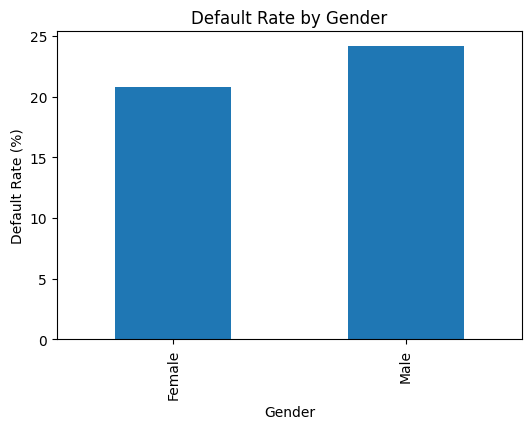

In [12]:
# Default Rate by Gender

gender_default_rate = pd.crosstab(
    df['Gender_Label'],
    df['Default'],
    normalize='index'
) * 100

display(gender_default_rate)

gender_default_rate[1].plot(kind='bar', figsize=(6,4))
plt.title('Default Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Default Rate (%)')
plt.show()

**Observation:**  
Default rates were analyzed using percentages instead of raw counts to avoid misleading conclusions.

## 10. Default Rate by Education
Default behavior was analyzed across different education levels.



Default,0,1
Education_Label,,
Graduate School,80.765234,19.234766
High School,74.842384,25.157616
Others,92.948718,7.051282
University,76.265146,23.734854


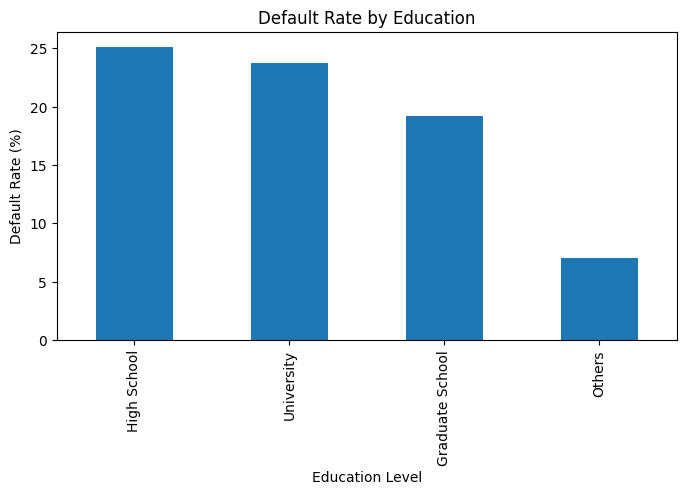

In [13]:
# Default Rate by Education

education_default_rate = pd.crosstab(
    df['Education_Label'],
    df['Default'],
    normalize='index'
) * 100

display(education_default_rate)

education_default_rate[1].sort_values(ascending=False).plot(kind='bar', figsize=(8,4))
plt.title('Default Rate by Education')
plt.xlabel('Education Level')
plt.ylabel('Default Rate (%)')
plt.show()

**Observation:**  
Education level shows some variation in default behavior, but it is not the strongest predictor.

## 11. Default Rate by Marital Status
Default rate was compared across marital status categories.



Default,0,1
Marriage_Label,,
Married,76.528296,23.471704
Others,76.392573,23.607427
Single,79.071661,20.928339


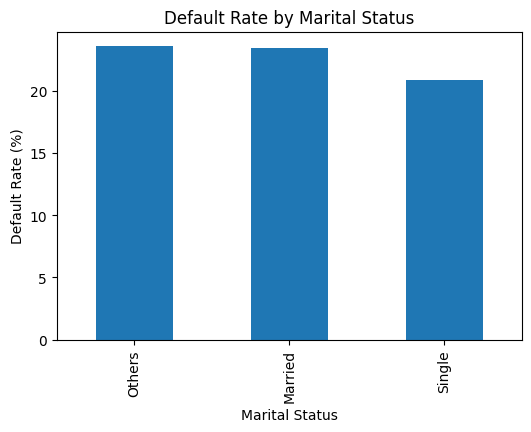

In [14]:
# Default Rate by Marital Status

marriage_default_rate = pd.crosstab(
    df['Marriage_Label'],
    df['Default'],
    normalize='index'
) * 100

display(marriage_default_rate)

marriage_default_rate[1].sort_values(ascending=False).plot(kind='bar', figsize=(6,4))
plt.title('Default Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Default Rate (%)')
plt.show()

**Observation:**  
Marital status provides basic demographic insight but does not dominate default prediction.

## 12. Age Distribution and Default
Customer age distribution and its relationship with default were analyzed.



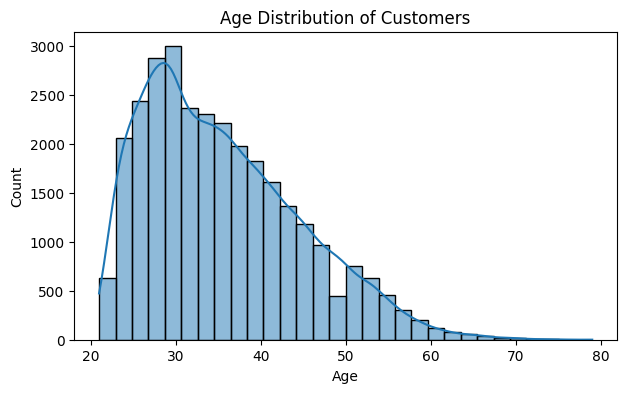

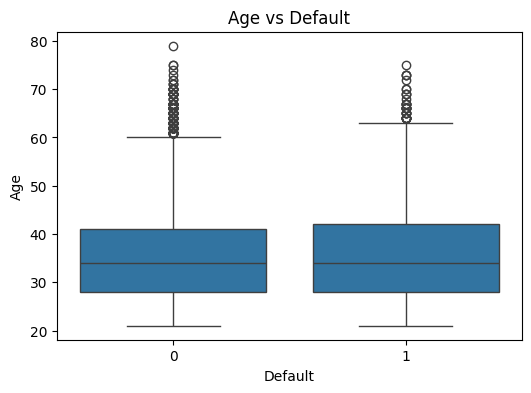

In [15]:
# Age Distribution and Age vs Default

plt.figure(figsize=(7,4))
sns.histplot(df['AGE'], bins=30, kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='Default', y='AGE', data=df)
plt.title('Age vs Default')
plt.xlabel('Default')
plt.ylabel('Age')
plt.show()

**Observation:**  
Most customers are concentrated in the 25–45 age group.

## 13. Credit Limit Analysis
Credit limit distribution and its relationship with default were studied.



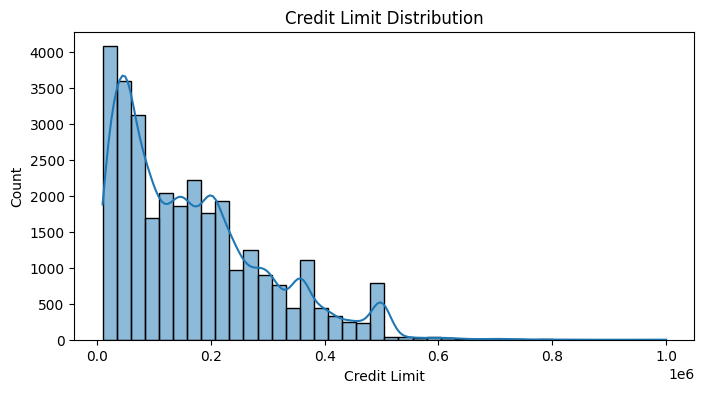

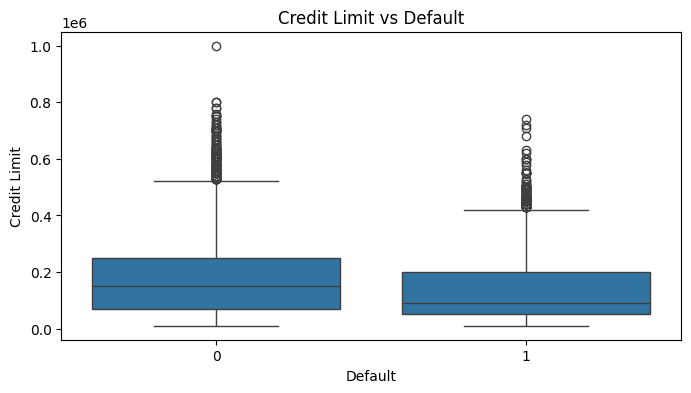

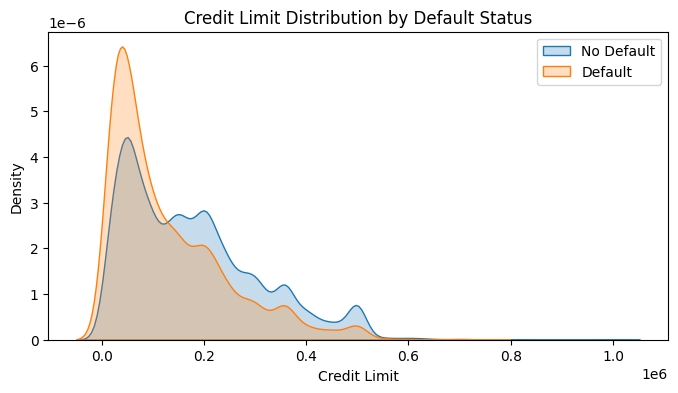

In [16]:
# Credit Limit Distribution and Credit Limit vs Default

plt.figure(figsize=(8,4))
sns.histplot(df['Credit_Limit'], bins=40, kde=True)
plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='Default', y='Credit_Limit', data=df)
plt.title('Credit Limit vs Default')
plt.xlabel('Default')
plt.ylabel('Credit Limit')
plt.show()

plt.figure(figsize=(8,4))
sns.kdeplot(df[df['Default'] == 0]['Credit_Limit'], label='No Default', fill=True)
sns.kdeplot(df[df['Default'] == 1]['Credit_Limit'], label='Default', fill=True)
plt.title('Credit Limit Distribution by Default Status')
plt.xlabel('Credit Limit')
plt.ylabel('Density')
plt.legend()
plt.show()

**Observation:**  
Customers with lower credit limits tend to show relatively higher default risk

## 14. Repayment Status Analysis
Repayment status across previous months was analyzed against default.



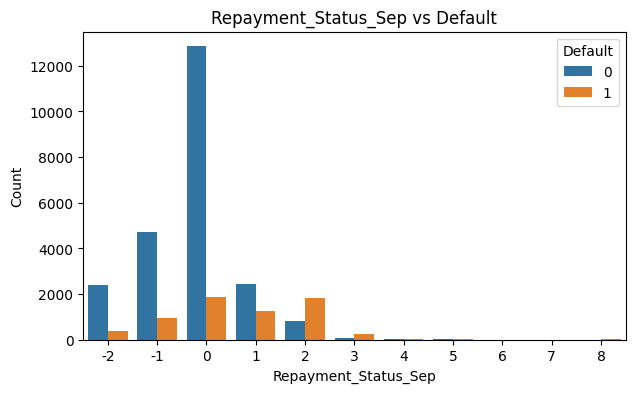

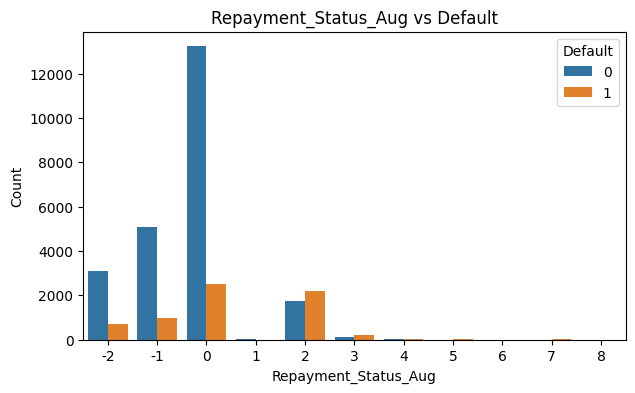

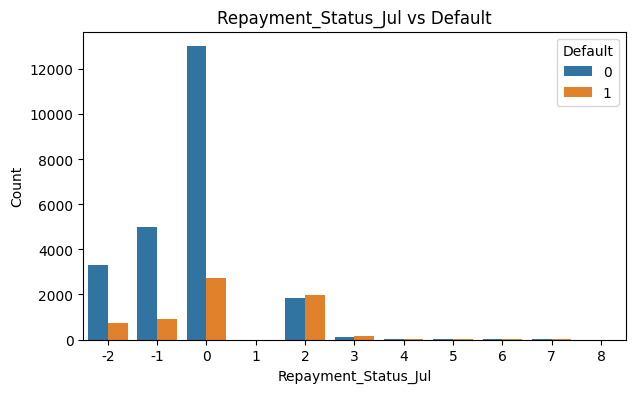

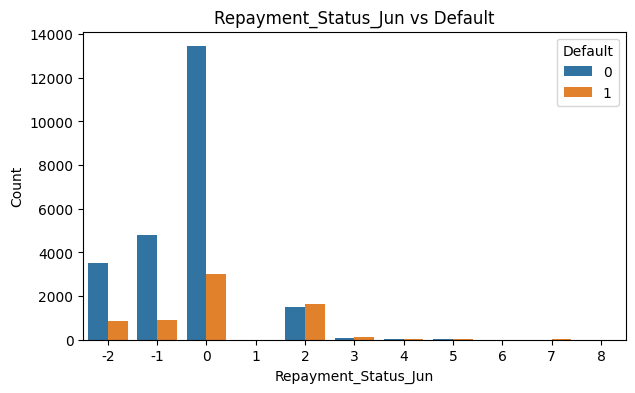

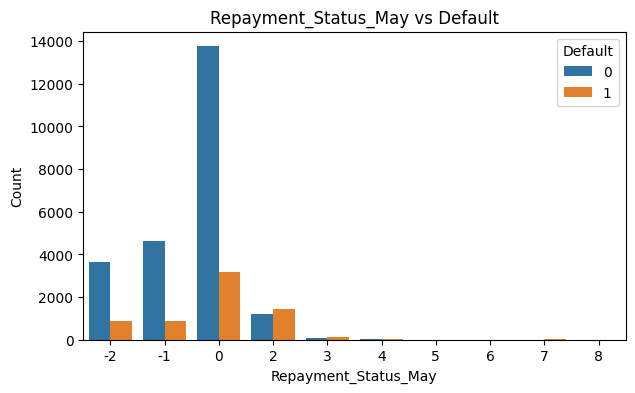

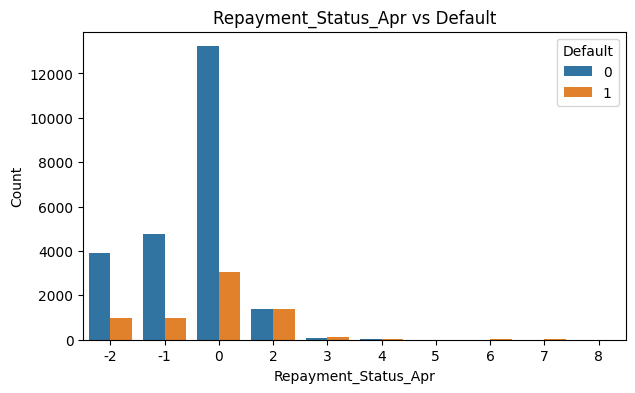

In [17]:
# Payment History vs Default

repayment_cols = [
    'Repayment_Status_Sep',
    'Repayment_Status_Aug',
    'Repayment_Status_Jul',
    'Repayment_Status_Jun',
    'Repayment_Status_May',
    'Repayment_Status_Apr'
]

for col in repayment_cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, hue='Default', data=df)
    plt.title(f'{col} vs Default')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

**Observation:**  
Recent repayment behavior is one of the strongest indicators of future default.

## 15. Bill Amount and Payment Amount Distribution
Latest bill amount and payment amount distributions were examined.



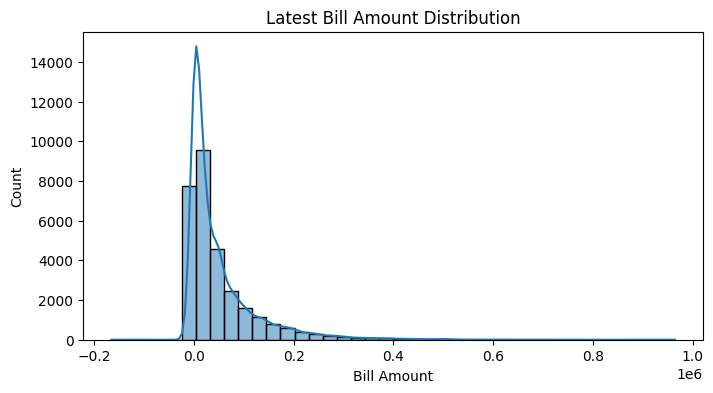

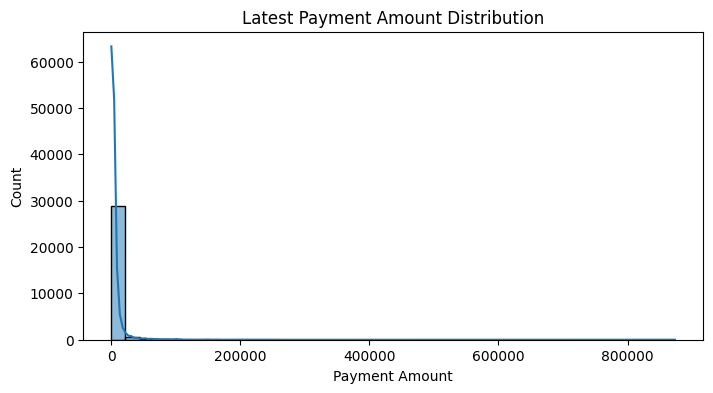

In [18]:
# Bill Amount and Payment Amount Distribution

bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
             'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

pay_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
            'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

# Instead of 12 messy plots, use only latest month + summary
plt.figure(figsize=(8,4))
sns.histplot(df['BILL_AMT1'], bins=40, kde=True)
plt.title('Latest Bill Amount Distribution')
plt.xlabel('Bill Amount')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df['PAY_AMT1'], bins=40, kde=True)
plt.title('Latest Payment Amount Distribution')
plt.xlabel('Payment Amount')
plt.ylabel('Count')
plt.show()

**Observation:**  
Both variables are right-skewed, indicating that most customers have smaller amounts while a few have very large values.

## 16. Feature Engineering
New features were created to better capture customer credit behavior.

Created features:
- Total_Bill
- Total_Payment
- Utilization_Ratio
- Payment_to_Bill_Ratio

**Observation:**  
Utilization Ratio is especially important because it reflects how much of the available credit limit is being used.

In [19]:
import numpy as np

# Feature Engineering

df['Total_Bill'] = df[bill_cols].sum(axis=1)
df['Total_Payment'] = df[pay_cols].sum(axis=1)

df['Utilization_Ratio'] = df['Total_Bill'] / df['Credit_Limit']

# Payment-to-bill ratio
df['Payment_to_Bill_Ratio'] = df['Total_Payment'] / df['Total_Bill'].replace(0, np.nan)

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill ratio missing values with 0
df['Payment_to_Bill_Ratio'] = df['Payment_to_Bill_Ratio'].fillna(0)

## 17. Engineered Feature Summary
Summary statistics of newly created features were analyzed.



In [20]:
# Engineered Feature Summary

engineered_features = [
    'Total_Bill',
    'Total_Payment',
    'Utilization_Ratio',
    'Payment_to_Bill_Ratio'
]

display(df[engineered_features].describe())

,Total_Bill,Total_Payment,Utilization_Ratio,Payment_to_Bill_Ratio
count,3.000000e+04,3.000000e+04,30000.000000,30000.000000
mean,2.698617e+05,3.165139e+04,2.238288,0.380941
std,3.795643e+05,6.082768e+04,2.111340,7.671004
min,-3.362590e+05,0.000000e+00,-1.395540,-546.928571
25%,2.868800e+04,6.679750e+03,0.179982,0.040952
50%,1.263110e+05,1.438300e+04,1.709004,0.084932
75%,3.426265e+05,3.350350e+04,4.127575,0.586922
max,5.263883e+06,3.764066e+06,32.185850,797.000000


**Observation:**  
Utilization Ratio shows variation across customers and can help identify risky credit usage behavior.

## 18. Engineered Features vs Default
Engineered features were compared with default status.



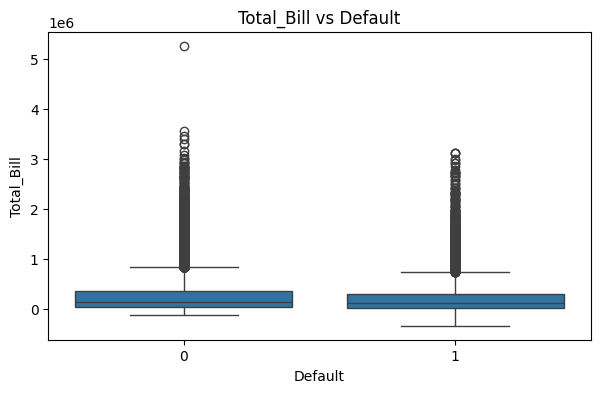

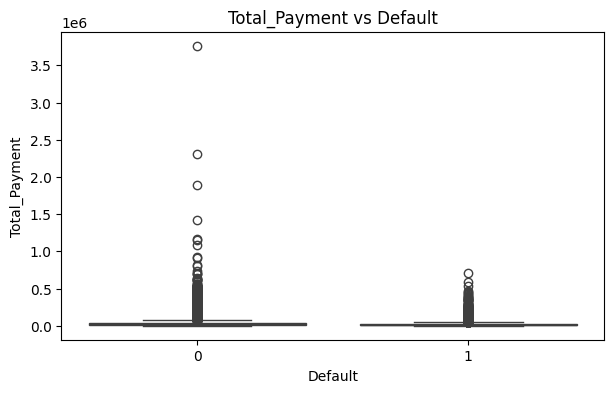

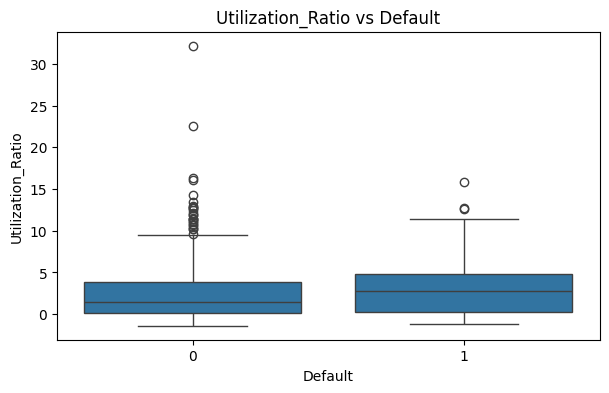

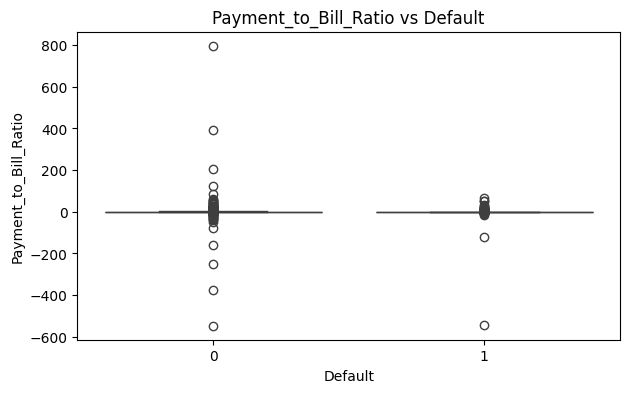

In [21]:
# Engineered Features vs Default

for col in engineered_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x='Default', y=col, data=df)
    plt.title(f'{col} vs Default')
    plt.xlabel('Default')
    plt.ylabel(col)
    plt.show()

**Observation:**  
Customers with higher utilization behavior tend to show higher default risk.

## 19. Correlation with Default
Correlation analysis was performed to identify variables associated with default.


,Default
Default,1.000000
Repayment_Status_Sep,0.324794
Repayment_Status_Aug,0.263551
Repayment_Status_Jul,0.235253
Repayment_Status_Jun,0.216614
Repayment_Status_May,0.204149
Repayment_Status_Apr,0.186866
Utilization_Ratio,0.115483
Education,0.033842
AGE,0.013890


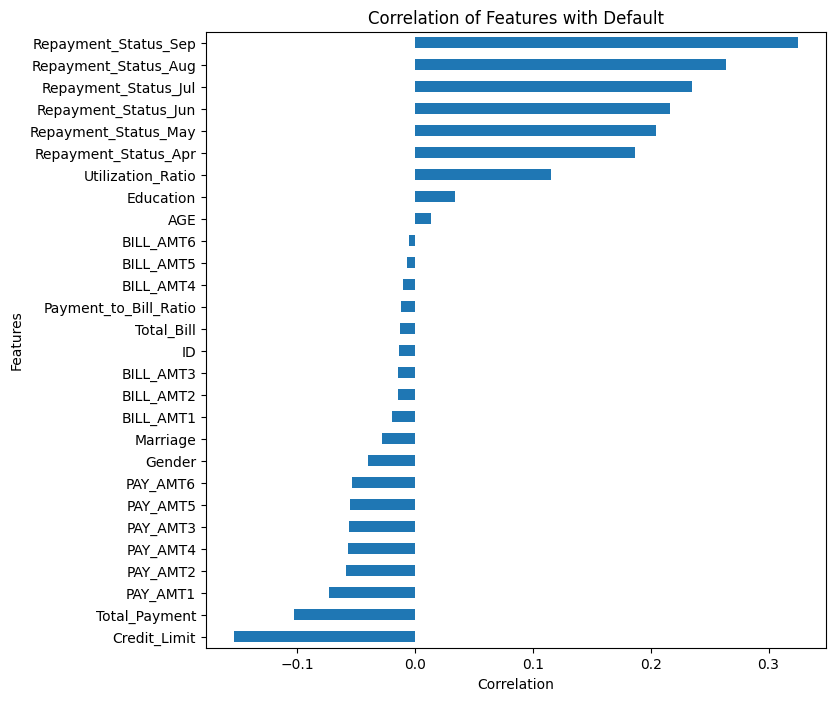

In [22]:
#Correlation with Target Variable

corr_with_default = df.corr(numeric_only=True)['Default'].sort_values(ascending=False)

display(corr_with_default)

plt.figure(figsize=(8,8))
corr_with_default.drop('Default').sort_values().plot(kind='barh')
plt.title('Correlation of Features with Default')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.show()


**Observation:**  
Repayment status variables showed the strongest positive correlation with default. Credit limit showed a negative relationship with default.

## 20. Correlation Heatmap
A heatmap was used to visualize relationships among important variables.


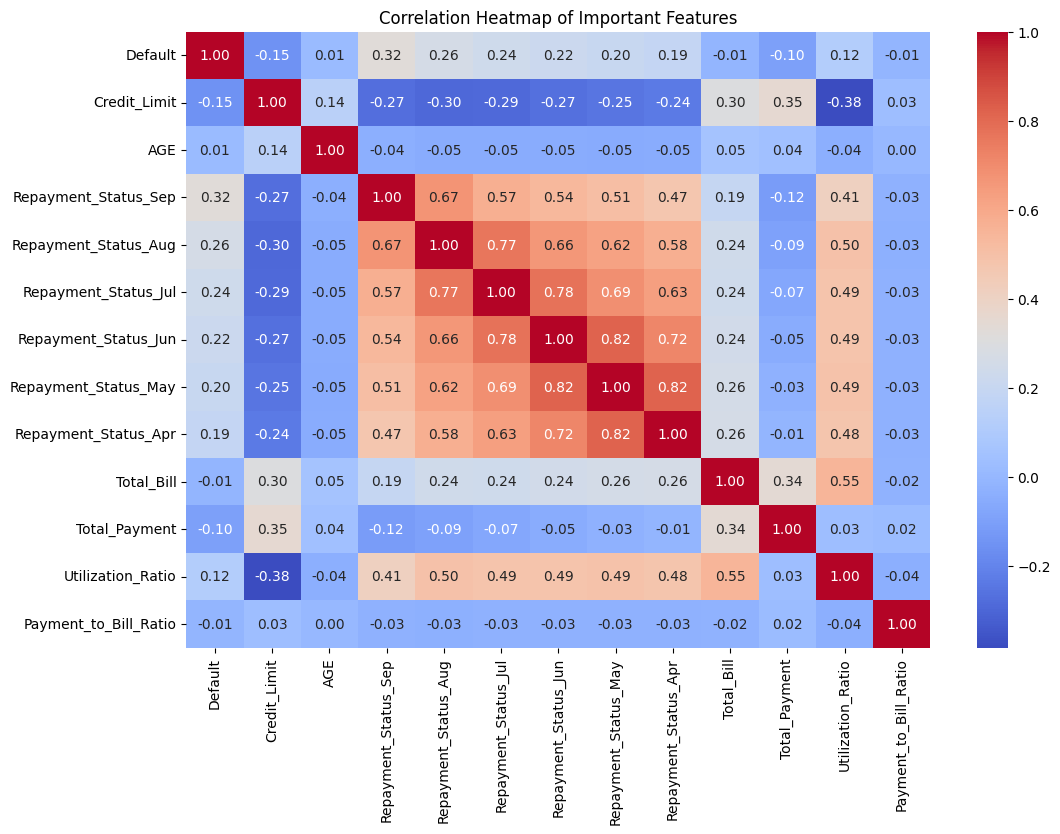

In [23]:
# Correlation Heatmap for Important Variables Only

important_cols = [
    'Default',
    'Credit_Limit',
    'AGE',
    'Repayment_Status_Sep',
    'Repayment_Status_Aug',
    'Repayment_Status_Jul',
    'Repayment_Status_Jun',
    'Repayment_Status_May',
    'Repayment_Status_Apr',
    'Total_Bill',
    'Total_Payment',
    'Utilization_Ratio',
    'Payment_to_Bill_Ratio'
]

plt.figure(figsize=(12,8))
sns.heatmap(
    df[important_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Correlation Heatmap of Important Features')
plt.show()


**Observation:**  
Repayment status variables are strongly related to each other and also show meaningful association with default.

## 21. VIF Analysis
Variance Inflation Factor was used to check multicollinearity among predictors.



In [24]:

# VIF Analysis

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use numeric variables only
X_vif = df.drop('Default', axis=1)
X_vif = X_vif.select_dtypes(include=['int64', 'float64'])

# Drop ID before VIF because ID is not a predictor
if 'ID' in X_vif.columns:
    X_vif = X_vif.drop('ID', axis=1)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data.sort_values(by='VIF', ascending=False)

display(vif_data)

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
21,PAY_AMT5,inf
20,PAY_AMT4,inf
19,PAY_AMT3,inf
18,PAY_AMT2,inf
17,PAY_AMT1,inf
16,BILL_AMT6,inf
15,BILL_AMT5,inf
14,BILL_AMT4,inf
13,BILL_AMT3,inf
12,BILL_AMT2,inf


**Observation:**  
Total_Bill and Total_Payment showed perfect multicollinearity because they were created from monthly bill and payment variables. Therefore, they were removed from the final modeling dataset.

## 22. Final Dataset for Modeling
A final modeling dataset was prepared after removing unnecessary and highly collinear variables.

**Observation:**  
The final dataset contains 24 predictor variables and 1 target variable.

In [25]:
# Final Dataset for Modeling
df_model = df.copy()

# Drop columns not required for modeling
columns_to_drop = [
    'ID',
    'Total_Bill',
    'Total_Payment',
    'Payment_to_Bill_Ratio',
    'Gender_Label',
    'Education_Label',
    'Marriage_Label'
]

# Drop only those columns that actually exist
df_model = df_model.drop(
    columns=[col for col in columns_to_drop if col in df_model.columns],
    axis=1
)

display(df_model.head())
print("Final modeling dataset shape:", df_model.shape)

print("Final columns:")
print(df_model.columns.tolist())

,Credit_Limit,Gender,Education,Marriage,AGE,Repayment_Status_Sep,Repayment_Status_Aug,Repayment_Status_Jul,Repayment_Status_Jun,Repayment_Status_May,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,Default,Utilization_Ratio
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,0.385200
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,0.142308
2,90000.0,2,2,2,34,0,0,0,0,0,...,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,1.129478
3,50000.0,2,2,1,37,0,0,0,0,0,...,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,4.626680
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,2.186780


Final modeling dataset shape: (30000, 25)
Final columns:
['Credit_Limit', 'Gender', 'Education', 'Marriage', 'AGE', 'Repayment_Status_Sep', 'Repayment_Status_Aug', 'Repayment_Status_Jul', 'Repayment_Status_Jun', 'Repayment_Status_May', 'Repayment_Status_Apr', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default', 'Utilization_Ratio']


## 23. Feature and Target Separation
The data was separated into independent variables `X` and target variable `y`.

In [26]:
# Define Features and Target

X = df_model.drop('Default', axis=1)
y = df_model['Default']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (30000, 24)
Shape of y: (30000,)


## 24. Train-Test Split
The dataset was split into training and testing sets using an 80:20 ratio.



In [27]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (24000, 24)
Testing set shape: (6000, 24)


**Observation:**  
Stratified splitting was used to maintain the same default proportion in both training and testing sets.

## 25. Feature Scaling
StandardScaler was applied to scale the features.

Scaling is important for Logistic Regression because it is sensitive to feature magnitude.

In [28]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


## 26. Logistic Regression Model
Logistic Regression was used as the baseline statistical classification model.

In [29]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression Model Trained Successfully")


Logistic Regression Model Trained Successfully


## 27. Logistic Regression Evaluation
The model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


In [30]:
# Logistic Regression Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision :", precision_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8093333333333333
Precision : 0.6967741935483871
Recall : 0.24415975885455915
F1 Score : 0.36160714285714285
ROC-AUC : 0.7088265881812996

Classification Report

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.70      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.76      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000




**Observation:**  
Logistic Regression gave good accuracy, but recall was low, indicating that many actual defaulters were missed.

## 28. Confusion Matrix
The confusion matrix was used to understand correct and incorrect classifications.



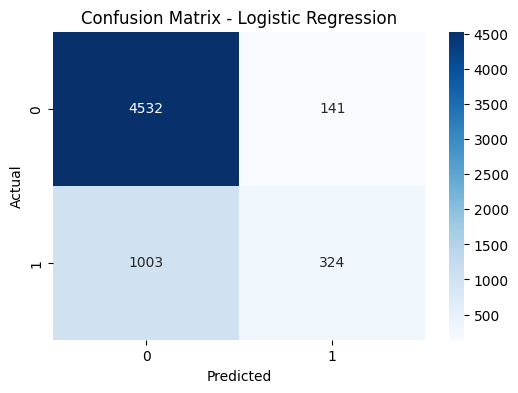

In [31]:
#Confusion Matrix

plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**Observation:**  
The model performed well in identifying non-defaulters but missed several defaulters.

## 29. ROC Curve
The ROC curve was plotted to evaluate the model’s ability to distinguish between defaulters and non-defaulters.



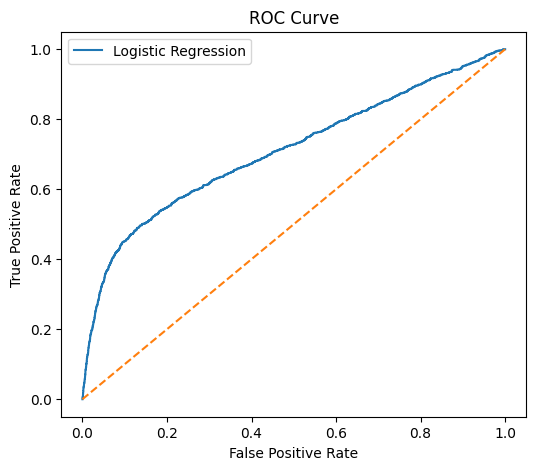

In [32]:
# ROC Curve


from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1],[0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

**Observation:**  
The ROC curve showed that the model performed better than random classification.

## 30. Random Forest Model
Random Forest was used as an ensemble-based comparison model.

In [33]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
     n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


## 31. Random Forest Evaluation
Random Forest was evaluated using the same classification metrics.


In [34]:
#  Random Forest Evaluation

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision :", precision_score(y_test, y_pred_rf))
print("Recall :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.8143333333333334
Precision : 0.642570281124498
Recall : 0.3617181612660136
F1 Score : 0.46287367405978785
ROC-AUC : 0.753310758738289

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.81      0.79      6000




**Observation:**  
Random Forest improved recall and F1 Score compared to Logistic Regression.

## 32. Feature Importance
Feature importance was extracted from the Random Forest model.



,Feature,Importance
5,Repayment_Status_Sep,0.094742
23,Utilization_Ratio,0.064917
4,AGE,0.063348
0,Credit_Limit,0.054277
11,BILL_AMT1,0.053711
12,BILL_AMT2,0.049084
17,PAY_AMT1,0.048177
13,BILL_AMT3,0.047050
16,BILL_AMT6,0.046821
14,BILL_AMT4,0.046751


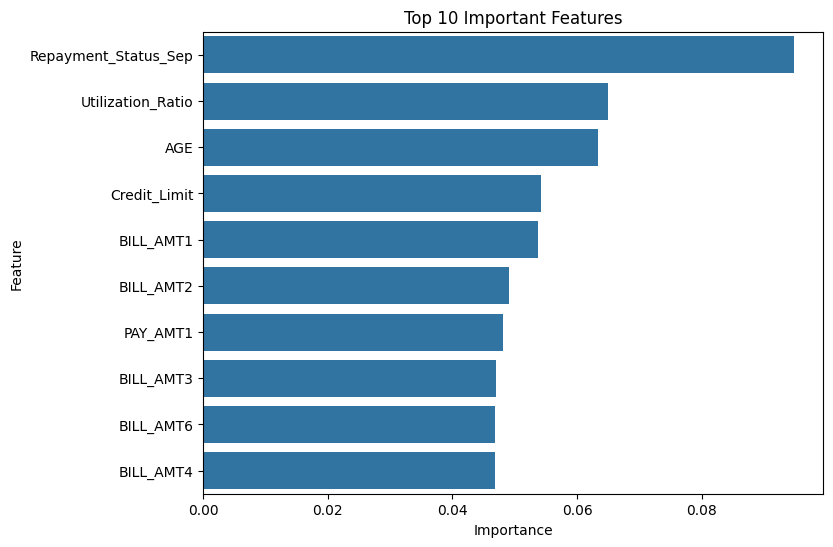

In [35]:
#  Feature Importance


importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

display(importance.head(10))

plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Important Features')
plt.show()

**Observation:**  
Repayment_Status_Sep and Utilization_Ratio emerged as important predictors of default risk.

## 33. XGBoost Model
XGBoost was used as an advanced boosting-based classification model.

In [36]:
!pip install xgboost

# XGBoost


from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


## 34. XGBoost Evaluation
XGBoost was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.



In [37]:
#  XGBoost Evaluation


print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision :", precision_score(y_test, y_pred_xgb))
print("Recall :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC :", roc_auc_score(y_test, y_prob_xgb))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_xgb))

Accuracy : 0.8166666666666667
Precision : 0.6565517241379311
Recall : 0.35870384325546345
F1 Score : 0.46393762183235865
ROC-AUC : 0.7754213747915482

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



**Observation:**  
XGBoost achieved the strongest overall baseline performance.

## 35. Comparison of Machine Learning Models

Models were compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.


Logistic Regression, Random Forest, and XGBoost were compared.



In [38]:
# Model Comparison


comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.809333,0.696774,0.244160,0.361607,0.708827
1,Random Forest,0.814333,0.642570,0.361718,0.462874,0.753311
2,XGBoost,0.816667,0.656552,0.358704,0.463938,0.775421


**Observation:**  
XGBoost gave the highest ROC-AUC among baseline models

## 36. Addressing Class Imbalance

Since the dataset is imbalanced, class weighting techniques were incorporated to improve the identification of defaulters.

In [39]:
# Handle Class Imbalance


# Balanced Logistic Regression
lr_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_balanced.fit(X_train_scaled, y_train)

y_pred_lr_bal = lr_balanced.predict(X_test_scaled)
y_prob_lr_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]


# Balanced Random Forest
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf_balanced.fit(X_train, y_train)

y_pred_rf_bal = rf_balanced.predict(X_test)
y_prob_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]


# Balanced XGBoost
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

xgb_balanced.fit(X_train, y_train)

y_pred_xgb_bal = xgb_balanced.predict(X_test)
y_prob_xgb_bal = xgb_balanced.predict_proba(X_test)[:, 1]

print("Balanced models trained successfully.")
print("Scale pos weight for XGBoost:", scale_pos_weight)

Balanced models trained successfully.
Scale pos weight for XGBoost: 3.520625353173856


## 37. Comparison of Balanced Models

Observation:
- Balanced XGBoost achieved the best trade-off between Recall and ROC-AUC.

In [40]:
# Compare Balanced Models


balanced_comparison = pd.DataFrame({
    'Model': [
        'Balanced Logistic Regression',
        'Balanced Random Forest',
        'Balanced XGBoost'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr_bal),
        accuracy_score(y_test, y_pred_rf_bal),
        accuracy_score(y_test, y_pred_xgb_bal)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr_bal),
        precision_score(y_test, y_pred_rf_bal),
        precision_score(y_test, y_pred_xgb_bal)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr_bal),
        recall_score(y_test, y_pred_rf_bal),
        recall_score(y_test, y_pred_xgb_bal)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr_bal),
        f1_score(y_test, y_pred_rf_bal),
        f1_score(y_test, y_pred_xgb_bal)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr_bal),
        roc_auc_score(y_test, y_prob_rf_bal),
        roc_auc_score(y_test, y_prob_xgb_bal)
    ]
})

display(balanced_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Balanced Logistic Regression,0.684500,0.371480,0.616428,0.463587,0.709555
1,Balanced Random Forest,0.812333,0.644189,0.338357,0.443676,0.756524
2,Balanced XGBoost,0.760833,0.468786,0.611153,0.530586,0.776357


## 38. Final Model Selection
Balanced XGBoost was selected as the final model.


In [41]:
# Final Model Selection

final_model_name = "Balanced XGBoost"

print("Final Selected Model:", final_model_name)
print("Reason: Balanced XGBoost gives the best balance between Recall, F1 Score and ROC-AUC for credit default prediction.")

Final Selected Model: Balanced XGBoost
Reason: Balanced XGBoost gives the best balance between Recall, F1 Score and ROC-AUC for credit default prediction.



**Reason:**  
In credit default prediction, missing actual defaulters is costly. Therefore, Recall and ROC-AUC were prioritized over Accuracy.

## 39. Confusion Matrix for Final Model

The confusion matrix was plotted for the final selected model, Balanced XGBoost.



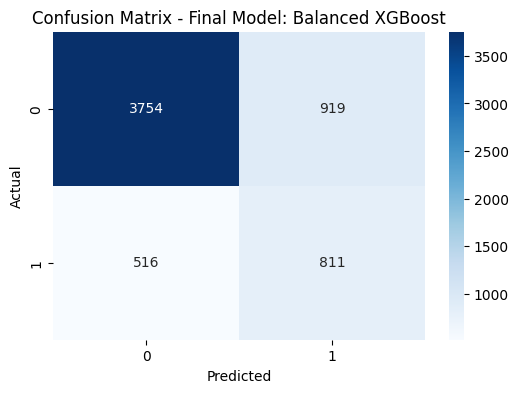

In [42]:
# Final Confusion Matrix - Balanced XGBoost


from sklearn.metrics import confusion_matrix

cm_final = confusion_matrix(y_test, y_pred_xgb_bal)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Final Model: Balanced XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The final Balanced XGBoost model correctly identified 811 actual defaulters and missed 516 defaulters. Compared to the baseline Logistic Regression model, the number of correctly identified defaulters increased substantially. Although false positives increased, this trade-off is acceptable in credit risk analytics because missing actual defaulters can lead to greater financial loss.

## 40. ROC Curve for Final Model

The ROC curve was used to evaluate the final model’s ability to distinguish between defaulters and non-defaulters.



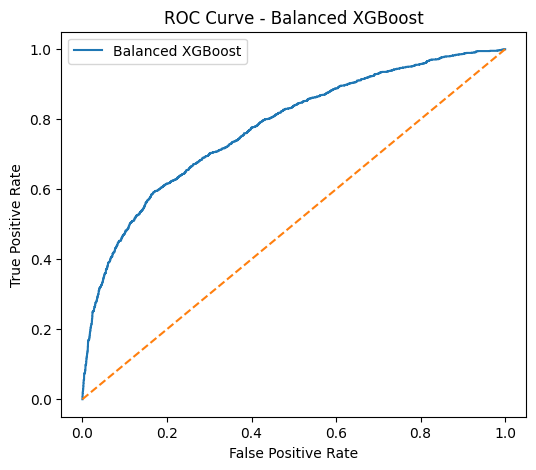

ROC-AUC: 0.7754213747915482


In [43]:
#  ROC Curve - Final Model


from sklearn.metrics import roc_curve, roc_auc_score

fpr_final, tpr_final, thresholds_final = roc_curve(y_test, y_prob_xgb_bal)

plt.figure(figsize=(6,5))
plt.plot(fpr_final, tpr_final, label='Balanced XGBoost')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model: Balanced XGBoost')
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_bal))

The ROC curve shows that the final Balanced XGBoost model performs better than random classification. The ROC-AUC score of approximately 0.776 indicates that the model has good ability to distinguish between defaulters and non-defaulters.

## 41. Feature Importance for Final Model

Feature importance was extracted from the final Balanced XGBoost model to identify the most influential predictors of default.



,Feature,Importance
5,Repayment_Status_Sep,0.472471
7,Repayment_Status_Jul,0.054154
6,Repayment_Status_Aug,0.053371
8,Repayment_Status_Jun,0.049903
18,PAY_AMT2,0.030922
10,Repayment_Status_Apr,0.030097
9,Repayment_Status_May,0.030059
23,Utilization_Ratio,0.021683
19,PAY_AMT3,0.021305
17,PAY_AMT1,0.019868


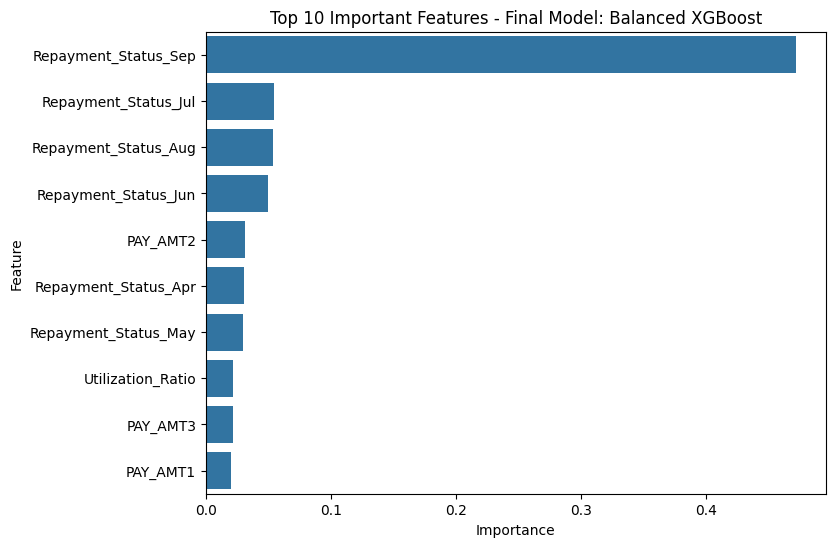

In [49]:
#  Feature Importance - Final Model


xgb_final_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_balanced.feature_importances_
})

xgb_final_importance = xgb_final_importance.sort_values(
    by='Importance',
    ascending=False
)

display(xgb_final_importance.head(10))

plt.figure(figsize=(8,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=xgb_final_importance.head(10)
)

plt.title('Top 10 Important Features - Final Model: Balanced XGBoost')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Observation:**  
The feature importance plot shows that repayment status, utilization ratio, credit limit, bill amount, and payment amount variables are important predictors of default. This supports the EDA findings that recent repayment behaviour and credit usage are strong indicators of credit risk.

## 42: Cross-Validation of Final Balanced XGBoost Model

Cross-validation was performed to check whether the final model gives stable performance across different subsets of the data. Since the target variable is imbalanced, Stratified K-Fold Cross-Validation was used so that each fold maintains a similar proportion of defaulters and non-defaulters.

ROC-AUC and F1 Score were used because accuracy alone is not sufficient in credit default prediction.

In [54]:
# Cross-Validation of Final Balanced XGBoost Model


from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

# Calculate class imbalance ratio
scale_pos_weight_cv = y.value_counts()[0] / y.value_counts()[1]

# Define final model again for cross-validation
xgb_cv_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_cv,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Stratified K-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'recall': 'recall',
    'precision': 'precision'
}

cv_results = cross_validate(
    xgb_cv_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("Mean ROC-AUC:", cv_results['test_roc_auc'].mean())
print("Std ROC-AUC:", cv_results['test_roc_auc'].std())

print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Std F1 Score:", cv_results['test_f1'].std())

print("Mean Recall:", cv_results['test_recall'].mean())
print("Mean Precision:", cv_results['test_precision'].mean())

Mean ROC-AUC: 0.7811548346531423
Std ROC-AUC: 0.00518004391211223
Mean F1 Score: 0.5389898353057886
Std F1 Score: 0.01165057059905168
Mean Recall: 0.6231127600076266
Mean Precision: 0.4748935400688518


 The mean ROC-AUC score of approximately 0.781 with a very low standard deviation shows that the model performs consistently across different folds. This confirms that the model is not dependent only on one train-test split.

## 43. Threshold Tuning

By default, classification models use a threshold of 0.50. This means that if the predicted probability of default is greater than or equal to 0.50, the customer is classified as a defaulter.

However, in credit risk analytics, the threshold can be adjusted depending on the bank's risk appetite. A lower threshold identifies more actual defaulters but also increases false positives. A higher threshold reduces false positives but may miss more defaulters.

Therefore, threshold tuning was performed to study the trade-off between Precision, Recall, and F1 Score.

In [55]:
# Threshold Tuning for Final Balanced XGBoost


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb_bal >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()

    threshold_results.append({
        'Threshold': threshold,
        'Accuracy': accuracy_score(y_test, y_pred_threshold),
        'Precision': precision_score(y_test, y_pred_threshold),
        'Recall': recall_score(y_test, y_pred_threshold),
        'F1 Score': f1_score(y_test, y_pred_threshold),
        'True Negatives': tn,
        'False Positives': fp,
        'False Negatives': fn,
        'True Positives': tp
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1 Score,True Negatives,False Positives,False Negatives,True Positives
0,0.25,0.457500,0.278187,0.911078,0.426230,1536,3137,118,1209
1,0.30,0.537500,0.305898,0.859834,0.451256,2084,2589,186,1141
2,0.35,0.613667,0.342047,0.808591,0.480735,2609,2064,254,1073
3,0.40,0.677667,0.380747,0.730219,0.500517,3097,1576,358,969
4,0.45,0.729333,0.428157,0.666918,0.521509,3491,1182,442,885
5,0.50,0.760833,0.468786,0.611153,0.530586,3754,919,516,811
6,0.55,0.783333,0.509115,0.568199,0.537037,3946,727,573,754
7,0.60,0.796000,0.540016,0.523738,0.531752,4081,592,632,695


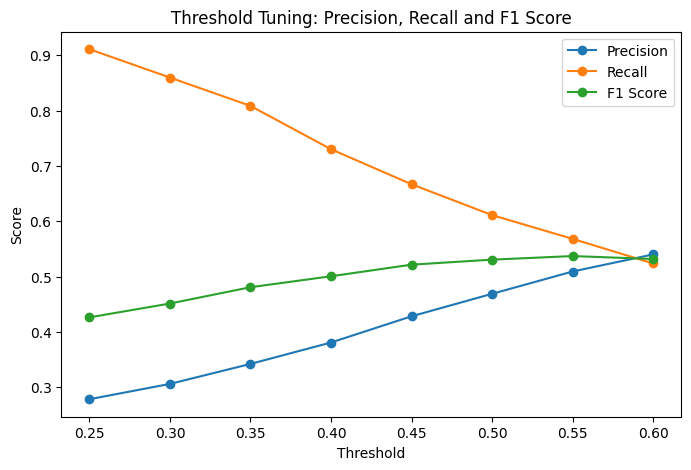

In [56]:
#  Precision-Recall-F1 Trade-off Plot


plt.figure(figsize=(8,5))

plt.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Threshold'], threshold_df['F1 Score'], marker='o', label='F1 Score')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Tuning: Precision, Recall and F1 Score')
plt.legend()
plt.show()

In [57]:
# Best Threshold Based on F1 Score


best_threshold = threshold_df.loc[
    threshold_df['F1 Score'].idxmax(),
    'Threshold'
]

print("Best Threshold based on F1 Score:", best_threshold)

Best Threshold based on F1 Score: 0.55


Threshold tuning shows the trade-off between Precision and Recall. At threshold 0.50, the model captures more defaulters with recall of 61.1%. At threshold 0.55, the F1-score improves slightly to 0.537, but recall decreases to 56.8%.

Since credit risk decisions depend on business cost and risk appetite, the final threshold can be adjusted by the bank. In this project, threshold tuning is presented as a business decision tool rather than replacing the main model result.

## Business Recommendations

1. Customers with delayed recent repayment status should be closely monitored because repayment history is the strongest predictor of default.

2. Customers with high utilization ratio should be considered higher risk because high credit usage may indicate financial stress.

3. The final Balanced XGBoost model can be used as an early warning system to identify customers who are likely to default.

4. Since recall improved after handling class imbalance, the model is more useful for credit risk analytics than a model that focuses only on accuracy.

5. Threshold tuning can be used based on the bank's business objective. If the bank wants to catch more defaulters, it can use a lower threshold. If the bank wants fewer false alarms, it can use a higher threshold.

## Conclusion

This project developed a machine learning framework for predicting credit card default risk.

The dataset was cleaned, validated, and explored through EDA. Feature engineering was performed to create risk-related variables such as utilization ratio. Multicollinearity was checked using VIF before model building.

Logistic Regression, Random Forest, and XGBoost were trained and compared. Since the target variable was imbalanced, class imbalance handling was applied using class weights and scale_pos_weight.

Balanced XGBoost was selected as the final model because it provided a better trade-off between Recall, F1 Score, and ROC-AUC. The final model achieved a recall of approximately 61.1% and ROC-AUC of approximately 0.776 on the test set.

Cross-validation further showed that the model performance was stable, with a mean ROC-AUC of approximately 0.781. Threshold tuning was also performed to understand the trade-off between precision and recall from a business perspective.

Overall, the project shows that repayment history, utilization ratio, credit limit, and payment behavior are important indicators of credit default risk.